In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve)
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
iris = load_iris()

In [15]:
features = iris.data
target = iris.target
train_features, test_features, train_target, test_target = train_test_split(features, target, test_size=1/3, random_state=21)
knn = KNeighborsClassifier()
knn.fit(train_features, train_target)
predictions = knn.predict(test_features)

***Accuracy score***

In [16]:
print(accuracy_score(test_target, predictions))

0.94


***Confustion matrix***

In [17]:
cm = confusion_matrix(test_target, predictions)
print(cm)

[[18  0  0]
 [ 0 16  1]
 [ 0  2 13]]


***Classification report***

In [18]:
print(classification_report(test_target, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.89      0.94      0.91        17
           2       0.93      0.87      0.90        15

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.94      0.94      0.94        50



***Prikaz matrice zbunjenosti pomoću heat mape***

Text(20.72222222222222, 0.5, 'Stvarno')

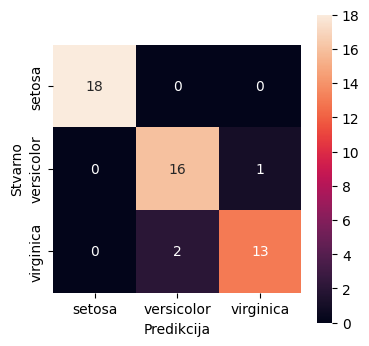

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax = sns.heatmap(cm, annot=True, square=True,
  xticklabels=iris.target_names,
  yticklabels=iris.target_names)
ax.set_xlabel('Predikcija')
ax.set_ylabel('Stvarno')

***Makro preciznost***

In [28]:
# Postupak računa
n_labels = len(np.unique(iris.target_names))
macro_precision = (np.diag(cm)/cm.sum(axis=0)).sum()/n_labels
print(macro_precision)

0.9391534391534391


In [30]:
# Using sklearn metrics
macro_precision_f = precision_score(test_target, predictions, average='macro')
print(macro_precision_f)

0.9391534391534391
